In [44]:
from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [45]:
# Set the project root to the parent of the current working directory
PROJECT_ROOT = Path.cwd().parent

# Create the path to the original raw dataset
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Create the path to the processed data directory
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Create the path to the processed MRI image folder
MRI_OUTPUT_DIR = PROCESSED_DIR / "mri"

# Display the main project directory
print("Project root:")
print(PROJECT_ROOT)

# Display the raw dataset directory
print("\nRaw data:")
print(RAW_DATA_DIR)

# Display the processed MRI output directory
print("\nProcessed MRI:")
print(MRI_OUTPUT_DIR)

Project root:
/Users/paulcollingwood/Documents/Source/parkinsons_ml

Raw data:
/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw

Processed MRI:
/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri


In [46]:
# Create the directory path for processed Parkinson's MRI images
PARKINSONS_DIR = (
    MRI_OUTPUT_DIR
    / "parkinsons"
)

# Create the directory path for processed control MRI images
CONTROL_DIR = (
    MRI_OUTPUT_DIR
    / "control"
)

# Create the Parkinson's directory if it does not already exist
PARKINSONS_DIR.mkdir(
    parents=True,   # Create any missing parent folders
    exist_ok=True   # Do not raise an error if the folder already exists
)

# Create the control directory if it does not already exist
CONTROL_DIR.mkdir(
    parents=True,   # Create any missing parent folders
    exist_ok=True   # Do not raise an error if the folder already exists
)

# Display the Parkinson's output directory
print(PARKINSONS_DIR)

# Display the control output directory
print(CONTROL_DIR)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri/parkinsons
/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri/control


In [47]:
# Find all NIfTI MRI files inside the raw dataset directory
nifti_files = [
    file
    for file in RAW_DATA_DIR.rglob("*")
    if file.name.lower().endswith(
        (".nii", ".nii.gz")
    )
]

# Display the total number of NIfTI files found
print(
    f"NIfTI files found: "
    f"{len(nifti_files)}"
)

NIfTI files found: 688


In [48]:
# Display the first 20 NIfTI files found in the raw dataset
for file in nifti_files[:20]:

    # Print each file path relative to the raw data directory
    # This keeps the output shorter and easier to read
    print(
        file.relative_to(
            RAW_DATA_DIR
        )
    )


mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909140447954_1_S191678_I388574.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_118726_NM_Reconstructed_DaTSCAN_Br_20220103151010900_1_S1092680_I1529627.nii
mri_datscan_ppmi/datscan b.tech/control/

In [49]:
# Loop through every NIfTI file found in the raw dataset
for file in nifti_files:

    try:
        # Load the NIfTI MRI file
        image = nib.load(file)

        # Display the relative file path and the MRI volume shape
        print(
            file.relative_to(
                RAW_DATA_DIR
            ),
            "->",
            image.shape
        )

    except Exception as error:

        # Display an error message if a file cannot be loaded
        print(
            "ERROR:",
            file.name,
            error
        )

mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii -> (91, 109, 91)
mri_datscan_ppmi/datscan b.tech/control/PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii -> (91, 109, 91)
mri_datscan_ppmi/datscan b.tech/control/PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii -> (91, 109, 91)
mri_datscan_ppmi/datscan b.tech/control/PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii -> (91, 109, 91)
mri_datscan_ppmi/datscan b.tech/control/PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii -> (91, 109, 91)
mri_datscan_ppmi/datscan b.tech/control/PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii -> (91, 109, 91)
mri_datscan_ppmi/datscan b.tech/control/PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909140447954_1_S191678_I388574.nii -> (91, 109, 91)
mri_datscan_ppmi/datscan b.tech/control/PPM

In [50]:
# Create an empty dictionary to count how many files
# have each number of dimensions
dimension_counts = {}

# Loop through every NIfTI file in the dataset
for file in nifti_files:

    try:
        # Load the NIfTI file
        image = nib.load(file)

        # Count how many dimensions the MRI data contains
        ndim = len(image.shape)

        # Add 1 to the count for this number of dimensions
        dimension_counts[ndim] = (
            dimension_counts.get(
                ndim,
                0
            )
            + 1
        )

    except Exception:
        # Skip any files that cannot be loaded
        pass


# Display a heading for the results
print("Dimensions found:")

# Display the number of files found for each dimensionality
for ndim, count in sorted(
    dimension_counts.items()
):
    print(
        f"{ndim}D: {count} files"
    )

Dimensions found:
2D: 1 files
3D: 687 files


In [51]:
# Define a function to select axial slices from a 3D MRI volume
def select_axial_slices(
    volume,
    offsets=(-10, -5, 0, 5, 10)
):

    # Check that the MRI volume contains exactly three dimensions
    if volume.ndim != 3:

        # Stop processing if the input is not a 3D volume
        raise ValueError(
            "Expected a 3D MRI volume, "
            f"but received shape "
            f"{volume.shape}"
        )

    # Find the index of the centre axial slice
    centre = (
        volume.shape[2] // 2
    )

    # Create an empty list to store the selected slices
    selected = []

    # Loop through each requested offset from the centre slice
    for offset in offsets:

        # Calculate the corresponding slice index
        index = centre + offset

        # Check that the calculated slice lies inside the MRI volume
        if (
            0
            <= index
            < volume.shape[2]
        ):

            # Store both the slice index and the 2D MRI slice
            selected.append(
                (
                    index,
                    volume[:, :, index]
                )
            )

    # Return the selected axial slices
    return selected

In [52]:
# Define a function to preprocess a single MRI slice
def preprocess_slice(
    image_slice,
    target_size=(224, 224)
):

    # Convert the MRI slice to 32-bit floating-point values
    image_slice = (
        image_slice.astype(
            np.float32
        )
    )

    # Find the minimum intensity value in the slice
    min_value = (
        image_slice.min()
    )

    # Find the maximum intensity value in the slice
    max_value = (
        image_slice.max()
    )

    # Normalise the image values to the range 0 to 1
    if max_value > min_value:

        image_slice = (
            image_slice
            - min_value
        ) / (
            max_value
            - min_value
        )

    else:

        # If all pixel values are identical,
        # replace the slice with zeros
        image_slice = (
            np.zeros_like(
                image_slice
            )
        )

    # Convert the normalised values from 0–1 to 0–255
    # and store them as 8-bit integers
    image_8bit = (
        image_slice * 255
    ).astype(
        np.uint8
    )

    # Convert the NumPy array into a PIL image
    image_pil = (
        Image.fromarray(
            image_8bit
        )
    )

    # Resize the MRI slice to the required target size
    image_pil = (
        image_pil.resize(
            target_size
        )
    )

    # Convert the resized PIL image back into a NumPy array
    return np.array(
        image_pil
    )

In [53]:
# Start with no example file selected
example_file = None

# Loop through each NIfTI file in the dataset
for file in nifti_files:

    # Load the NIfTI file
    image = nib.load(file)

    # Check whether the file contains a 3D MRI volume
    if len(image.shape) == 3:

        # Store the first 3D MRI file found
        example_file = file

        # Stop searching once a suitable file has been found
        break

# Display the selected example file
print(example_file)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw/mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii


In [54]:
# Load the selected example NIfTI MRI file
image = nib.load(
    example_file
)

# Convert the MRI data into a NumPy array
volume = image.get_fdata()

# Display the shape of the MRI volume
print(
    "Volume shape:",
    volume.shape
)

# Display the number of dimensions in the MRI volume
print(
    "Dimensions:",
    volume.ndim
)

Volume shape: (91, 109, 91)
Dimensions: 3


In [55]:
# Select several axial slices from around the centre of the MRI volume
selected_slices = (
    select_axial_slices(
        volume
    )
)

# Display the slice numbers that were selected
print(
    [
        index
        for index, _
        in selected_slices
    ]
)

[35, 40, 45, 50, 55]


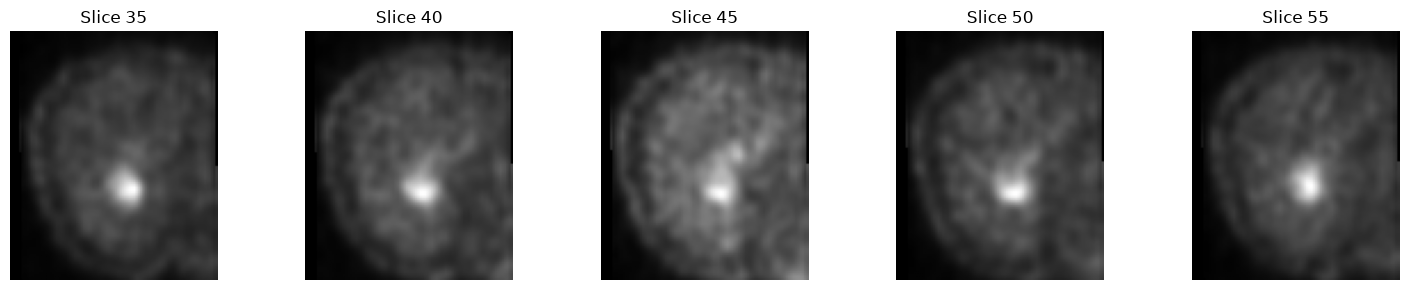

In [56]:
# Create a figure with one subplot for each selected axial MRI slice
fig, axes = plt.subplots(
    1,
    len(selected_slices),
    figsize=(15, 3)
)

# Loop through each subplot and its corresponding selected MRI slice
for ax, (
    slice_index,
    image_slice
) in zip(
    axes,
    selected_slices
):

    # Display the MRI slice in grayscale
    ax.imshow(
        image_slice.T,
        cmap="gray",
        origin="lower"
    )

    # Add the original slice number as the subplot title
    ax.set_title(
        f"Slice {slice_index}"
    )

    # Hide the axis labels and tick marks
    ax.axis("off")


# Adjust the spacing between the subplots
plt.tight_layout()

# Display all selected axial MRI slices
plt.show()

In [57]:
# Select the third MRI slice from the previously selected slices
slice_index, image_slice = (
    selected_slices[2]
)

# Preprocess the selected MRI slice
processed = (
    preprocess_slice(
        image_slice
    )
)

# Display the dimensions of the processed image
print(
    "Processed shape:",
    processed.shape
)

# Display the minimum pixel intensity after preprocessing
print(
    "Minimum:",
    processed.min()
)

# Display the maximum pixel intensity after preprocessing
print(
    "Maximum:",
    processed.max()
)

Processed shape: (224, 224)
Minimum: 0
Maximum: 255


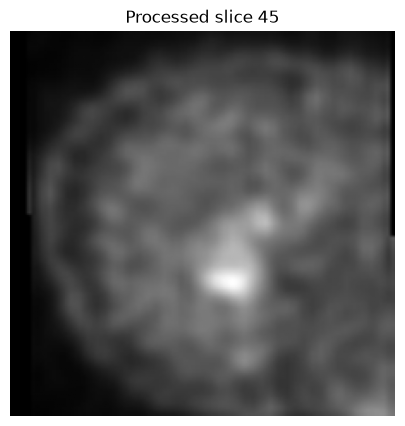

In [58]:
# Create a square figure for displaying the processed MRI slice
plt.figure(
    figsize=(5, 5)
)

# Display the processed MRI slice in grayscale
plt.imshow(
    processed.T,
    cmap="gray",
    origin="lower"
)

# Add a title showing which slice is being displayed
plt.title(
    f"Processed slice {slice_index}"
)

# Hide the axis labels and tick marks
plt.axis("off")

# Display the processed MRI image
plt.show()

In [59]:
# Define a function to extract a subject ID from a NIfTI filename
def get_subject_id(
    file_path
):

    # Get the filename including its extension
    name = file_path.name

    # Check for compressed NIfTI files ending in ".nii.gz"
    if name.lower().endswith(
        ".nii.gz"
    ):

        # Remove the final 7 characters: ".nii.gz"
        return name[:-7]

    # For normal ".nii" files, return the filename without the extension
    return file_path.stem

In [60]:
# Display the first 10 NIfTI filenames and their extracted subject IDs
for file in nifti_files[:10]:

    # Print the original filename followed by the subject ID
    # returned by the get_subject_id() function
    print(
        file.name,
        "->",
        get_subject_id(file)
    )

PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii -> PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345
PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii -> PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559
PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii -> PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074
PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii -> PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634
PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii -> PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391
PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii -> PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837
PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909

In [61]:
# Display the first 50 NIfTI files found in the raw dataset
for file in nifti_files[:50]:

    # Print each file path relative to the raw data directory
    # This makes the output shorter and easier to inspect
    print(
        file.relative_to(
            RAW_DATA_DIR
        )
    )

mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909140447954_1_S191678_I388574.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_118726_NM_Reconstructed_DaTSCAN_Br_20220103151010900_1_S1092680_I1529627.nii
mri_datscan_ppmi/datscan b.tech/control/

In [62]:
# Define a function to determine the class label from the file path
def get_class_from_path(
    file_path
):

    # Convert every part of the path to lowercase
    # so matching is not affected by capital letters
    parts = [
        part.lower()
        for part
        in file_path.parts
    ]

    # Define folder names that indicate a healthy/control subject
    control_terms = {
        "control",
        "controls",
        "healthy",
        "hc"
    }

    # Define folder names that indicate a Parkinson's subject
    parkinsons_terms = {
        "pd",
        "parkinson",
        "parkinsons",
        "parkinson's"
    }

    # Check each part of the file path
    for part in parts:

        # Return the control label if a matching control term is found
        if part in control_terms:
            return "control"

        # Return the Parkinson's label if a matching Parkinson's term is found
        if part in parkinsons_terms:
            return "parkinsons"

    # Return unknown if no recognised class term is found
    return "unknown"

In [63]:
# Display the first 50 NIfTI files together with their detected class labels
for file in nifti_files[:50]:

    # Print the file path relative to the raw data directory
    # followed by the class returned by get_class_from_path()
    print(
        file.relative_to(
            RAW_DATA_DIR
        ),
        "->",
        get_class_from_path(
            file
        )
    )

mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909140447954_1_S191678_I388574.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_118726_NM_Reconstructed_DaTSCAN_Br_20220

In [64]:
# Create an empty list to store valid 3D MRI files
mri_files = []

# Loop through every NIfTI file found in the dataset
for file in nifti_files:

    try:

        # Load the NIfTI file
        image = nib.load(
            file
        )

        # Get the dimensions of the MRI data
        shape = image.shape

        # Keep only files that contain 3D volumes
        if len(shape) == 3:

            mri_files.append(
                file
            )

    except Exception as error:

        # Display an error message if a file cannot be loaded
        print(
            f"Skipping {file.name}: "
            f"{error}"
        )


# Display the total number of valid 3D MRI files found
print(
    "3D candidate MRI files:",
    len(mri_files)
)

3D candidate MRI files: 687


In [65]:
# Display the first 50 valid 3D MRI files
for file in mri_files[:50]:

    # Print each file path relative to the raw data directory
    # so the output is shorter and easier to read
    print(
        file.relative_to(
            RAW_DATA_DIR
        )
    )

mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909140447954_1_S191678_I388574.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_118726_NM_Reconstructed_DaTSCAN_Br_20220103151010900_1_S1092680_I1529627.nii
mri_datscan_ppmi/datscan b.tech/control/

In [66]:
# Create a dictionary to store the number of MRI files in each class
class_counts = {
    "parkinsons": 0,
    "control": 0,
    "unknown": 0
}

# Loop through every valid 3D MRI file
for file in mri_files:

    # Determine the class of the MRI from its file path
    class_name = (
        get_class_from_path(
            file
        )
    )

    # Increase the count for the detected class by 1
    class_counts[
        class_name
    ] += 1

# Display the number of MRI files in each class
print(class_counts)

{'parkinsons': 0, 'control': 254, 'unknown': 433}


In [67]:
# Select the first valid 3D MRI file from the filtered list
example_file = (
    mri_files[0]
)

# Determine whether the MRI belongs to the Parkinson's
# or control class
class_name = (
    get_class_from_path(
        example_file
    )
)

# Extract the subject ID from the MRI filename
subject_id = (
    get_subject_id(
        example_file
    )
)

# Display the full path of the selected MRI file
print(
    "File:",
    example_file
)

# Display the detected class label
print(
    "Class:",
    class_name
)

# Display the extracted subject identifier
print(
    "Subject:",
    subject_id
)

File: /Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw/mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii
Class: control
Subject: PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345


In [68]:
# Load the selected 3D MRI file using nibabel
image = nib.load(
    example_file
)

# Convert the MRI volume into a NumPy array
volume = (
    image.get_fdata()
)

# Display the dimensions of the MRI volume
print(
    volume.shape
)

(91, 109, 91)


In [69]:
# Check whether the MRI volume has four dimensions
# with only one value in the fourth dimension
if (
    volume.ndim == 4
    and
    volume.shape[3] == 1
):

    # Remove the unnecessary fourth dimension
    # so the volume becomes a standard 3D MRI
    volume = (
        volume[:, :, :, 0]
    )


# Check that the MRI volume now has exactly three dimensions
if volume.ndim != 3:

    # Stop processing if the volume is still not 3D
    raise ValueError(
        "Expected a 3D MRI volume, "
        f"but got {volume.shape}"
    )

In [70]:
# Select several axial slices from around the centre of the MRI volume
selected_slices = (
    select_axial_slices(
        volume
    )
)

# Display the slice indices that were selected
print(
    [
        index
        for index, _
        in selected_slices
    ]
)

[35, 40, 45, 50, 55]


In [71]:
# Select the correct output directory based on the detected MRI class
if class_name == "parkinsons":

    # Store Parkinson's MRI slices in the Parkinson's folder
    output_dir = (
        PARKINSONS_DIR
    )

elif class_name == "control":

    # Store control MRI slices in the control folder
    output_dir = (
        CONTROL_DIR
    )

else:

    # Stop processing if the class could not be identified
    raise ValueError(
        "Unknown class for: "
        f"{example_file}"
    )

In [72]:
# Create an empty list to store metadata for every processed MRI slice
metadata = []

In [73]:
# Loop through each selected axial MRI slice
for (
    slice_index,
    image_slice
) in selected_slices:

    # Preprocess the current MRI slice
    processed = (
        preprocess_slice(
            image_slice
        )
    )

    # Create a unique output filename using the subject ID
    # and the original axial slice number
    output_file = (
        output_dir
        / (
            f"{subject_id}"
            f"_z{slice_index}.png"
        )
    )

    # Convert the processed NumPy array into a PIL image
    # and save it as a PNG file
    Image.fromarray(
        processed
    ).save(
        output_file
    )

    # Store metadata about the saved slice
    metadata.append({
        "subject_id":
            subject_id,

        "class":
            class_name,

        "slice_index":
            slice_index,

        "source_file":
            str(example_file),

        "processed_file":
            str(output_file)
    })

    # Display the name of the saved image file
    print(
        output_file.name
    )

PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z35.png
PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z40.png
PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z45.png
PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z50.png
PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z55.png


In [74]:
# Display the metadata collected for the processed MRI slices
metadata

[{'subject_id': 'PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345',
  'class': 'control',
  'slice_index': 35,
  'source_file': '/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw/mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii',
  'processed_file': '/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z35.png'},
 {'subject_id': 'PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345',
  'class': 'control',
  'slice_index': 40,
  'source_file': '/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw/mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii',
  'processed_file': '/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri/control/PPMI_203684_NM_Re

In [75]:
# Convert the metadata list into a pandas DataFrame
df = pd.DataFrame(
    metadata
)

# Display the DataFrame
df

,subject_id,class,slice_index,source_file,processed_file
0,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,35,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...
1,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,40,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...
2,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,45,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...
3,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,50,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...
4,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,55,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...


In [76]:
# Create the full path for the test metadata CSV file
metadata_test_file = (
    PROCESSED_DIR
    / "mri_metadata_test.csv"
)

# Save the metadata DataFrame as a CSV file
df.to_csv(
    metadata_test_file,
    index=False   # Do not save the DataFrame row numbers
)

# Display the location of the saved metadata file
print(
    metadata_test_file
)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri_metadata_test.csv


In [77]:
# Create an empty list to store metadata for every processed MRI slice
metadata = []

# Loop through every valid 3D MRI file
# enumerate() also gives each file a progress number starting from 1
for number, file in enumerate(
    mri_files,
    start=1
):

    # Display processing progress
    print(
        f"[{number}/{len(mri_files)}] "
        f"{file.name}"
    )

    # -----------------------------
    # Get class
    # -----------------------------

    # Determine whether the MRI belongs to the Parkinson's
    # or control class
    class_name = (
        get_class_from_path(
            file
        )
    )

    # Skip files where the class cannot be identified
    if class_name == "unknown":

        print(
            "  Skipping: "
            "unknown class"
        )

        continue


    # -----------------------------
    # Get subject ID
    # -----------------------------

    # Extract a subject identifier from the filename
    subject_id = (
        get_subject_id(
            file
        )
    )


    # -----------------------------
    # Load scan
    # -----------------------------

    try:

        # Load the NIfTI MRI file
        image = nib.load(
            file
        )

        # Convert the MRI data into a NumPy array
        volume = (
            image.get_fdata()
        )

    except Exception as error:

        # Skip the file if it cannot be loaded
        print(
            "  Failed to load:",
            error
        )

        continue


    # -----------------------------
    # Handle 4D with one channel
    # -----------------------------

    # Some MRI files may have an unnecessary fourth dimension
    # with a size of 1, for example (256, 256, 176, 1)
    if (
        volume.ndim == 4
        and
        volume.shape[3] == 1
    ):

        # Remove the final singleton dimension
        volume = (
            volume[:, :, :, 0]
        )


    # -----------------------------
    # Ignore non-3D images
    # -----------------------------

    # Skip any scan that is not a standard 3D MRI volume
    if volume.ndim != 3:

        print(
            "  Skipping unsupported "
            f"shape: {volume.shape}"
        )

        continue


    # -----------------------------
    # Select slices
    # -----------------------------

    try:

        # Select several axial slices around the centre
        # of the MRI volume
        selected_slices = (
            select_axial_slices(
                volume
            )
        )

    except ValueError as error:

        # Skip the scan if the slice selection fails
        print(
            "  Skipping:",
            error
        )

        continue


    # -----------------------------
    # Output folder
    # -----------------------------

    # Select the correct output directory
    # based on the MRI class
    if class_name == "parkinsons":

        output_dir = (
            PARKINSONS_DIR
        )

    else:

        output_dir = (
            CONTROL_DIR
        )


    # -----------------------------
    # Process slices
    # -----------------------------

    # Loop through each selected axial slice
    for (
        slice_index,
        image_slice
    ) in selected_slices:

        # Normalise and resize the MRI slice
        processed = (
            preprocess_slice(
                image_slice
            )
        )

        # Create a unique filename using the subject ID
        # and original axial slice number
        output_file = (
            output_dir
            / (
                f"{subject_id}"
                f"_z{slice_index}.png"
            )
        )

        # Save the processed slice as a PNG image
        Image.fromarray(
            processed
        ).save(
            output_file
        )


        # -------------------------
        # Metadata
        # -------------------------

        # Store information about the processed slice
        metadata.append({

            # Subject identifier
            "subject_id":
                subject_id,

            # Parkinson's or control class
            "class":
                class_name,

            # Original axial slice number
            "slice_index":
                slice_index,

            # Path to the original NIfTI file
            "source_file":
                str(file),

            # Path to the processed PNG file
            "processed_file":
                str(output_file),

            # Shape of the original 3D MRI volume
            "original_shape":
                str(volume.shape)

        })

[1/687] PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii
[2/687] PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii
[3/687] PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii
[4/687] PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii
[5/687] PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii
[6/687] PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii
[7/687] PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909140447954_1_S191678_I388574.nii
[8/687] PPMI_118726_NM_Reconstructed_DaTSCAN_Br_20220103151010900_1_S1092680_I1529627.nii
[9/687] PPMI_3353_NM_Reconstructed_DaTSCAN_Br_20121015085109857_1_S117591_I339904.nii
[10/687] PPMI_3064_NM_Reconstructed_DaTSCAN_Br_20121019114919650_1_S124289_I341217.nii
[11/687] PPMI_3151_NM_Reconstructed_DaTSCAN_Br_20121018133140192_1_S135844_I341018.nii
[12/687] PPMI_103467_NM_Reconstructe

In [78]:
# Convert the collected metadata into a pandas DataFrame
df = pd.DataFrame(
    metadata
)

# Display the number of rows and columns in the metadata table
print(
    "Metadata shape:",
    df.shape
)

# Display the first five rows of the DataFrame
df.head()

Metadata shape: (1270, 6)


,subject_id,class,slice_index,source_file,processed_file,original_shape
0,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,35,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
1,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,40,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
2,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,45,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
3,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,50,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
4,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,55,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"


In [79]:
# Create the full path for the final MRI metadata CSV file
metadata_file = (
    PROCESSED_DIR
    / "mri_metadata.csv"
)

# Save the complete metadata DataFrame as a CSV file
df.to_csv(
    metadata_file,
    index=False   # Do not save the DataFrame row numbers
)

# Display the location of the saved metadata file
print(
    metadata_file
)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri_metadata.csv


In [80]:
# Count how many processed MRI slices belong to each class
print(
    df["class"]
    .value_counts()
)

class
control    1270
Name: count, dtype: int64


In [ ]:
# Group the metadata by class and count the number
# of unique subjects in each class
subject_summary = (
    df.groupby(
        "class"
    )["subject_id"]
    .nunique()
)

# Display the number of unique subjects in each class
print(
    subject_summary
)

Problem with images not being classified for parkinsons patients

In [87]:
# Display the first 100 MRI file paths together with
# the class label detected from each file path
for file in mri_files[:100]:

    # Print the path relative to the raw data directory
    # followed by the detected class
    print(
        file.relative_to(
            RAW_DATA_DIR
        ),
        "->",
        get_class_from_path(
            file
        )
    )

mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909140447954_1_S191678_I388574.nii -> control
mri_datscan_ppmi/datscan b.tech/control/PPMI_118726_NM_Reconstructed_DaTSCAN_Br_20220

In [89]:
# Count how many candidate MRI files are detected
# as Parkinson's, control, or unknown
class_counts = {
    "parkinsons": 0,
    "control": 0,
    "unknown": 0
}

# Loop through every candidate MRI file
for file in mri_files:

    # Work out the class from the file path
    class_name = get_class_from_path(
        file
    )

    # Add 1 to the correct class count
    class_counts[class_name] += 1

# Display the final totals
print(class_counts)

{'parkinsons': 253, 'control': 254, 'unknown': 180}


In [90]:
# Create a list containing MRI files whose class
# could not be identified from their file path
unknown_files = [
    file
    for file in mri_files
    if get_class_from_path(file) == "unknown"
]

# Display the total number of unknown MRI files
print(
    "Unknown MRI files:",
    len(unknown_files)
)

# Display the first 50 unknown files
for file in unknown_files[:50]:

    # Print each path relative to the raw data directory
    # so the output is shorter and easier to inspect
    print(
        file.relative_to(
            RAW_DATA_DIR
        )
    )

Unknown MRI files: 180
mri_datscan_ppmi/Mri/PD-30/Copy of 27.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 26.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 32.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 18.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 31.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 25.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 19.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 21.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 20.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 22.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 23.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 9.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 8.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 5.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 4.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 6.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 7.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 3.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 2.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 1.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 12.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 13.nii
mri_datscan_ppmi/Mri/PD-30/Copy of 11.nii
mri_datscan_ppmi/Mri

In [91]:
# Define a function to determine the class label from the file path
def get_class_from_path(
    file_path
):

    # Convert every part of the path to lowercase
    parts = [
        part.lower()
        for part
        in file_path.parts
    ]

    # Folder names that indicate a healthy/control subject
    control_terms = {
        "control",
        "controls",
        "healthy",
        "hc"
    }

    # Folder names that indicate a Parkinson's subject
    parkinsons_terms = {
        "pd",
        "pdd",
        "parkinson",
        "parkinsons",
        "parkinson's"
    }

    # Check each part of the file path
    for part in parts:

        # Return control if a recognised control folder is found
        if part in control_terms:
            return "control"

        # Return Parkinson's if a recognised Parkinson's folder is found
        if part in parkinsons_terms:
            return "parkinsons"

    # Return unknown if no recognised class folder is found
    return "unknown"

In [92]:
# Count the number of MRI files detected in each class
class_counts = {
    "parkinsons": 0,
    "control": 0,
    "unknown": 0
}

# Loop through every candidate MRI file
for file in mri_files:

    # Determine the class from the file path
    class_name = get_class_from_path(
        file
    )

    # Increase the count for the detected class
    class_counts[class_name] += 1

# Display the total number of files in each class
print(class_counts)

{'parkinsons': 253, 'control': 254, 'unknown': 180}


In [93]:
# Select the first valid MRI file from the list
example_file = (
    mri_files[0]
)

# Determine the class label for the selected MRI file
class_name = (
    get_class_from_path(
        example_file
    )
)

# Extract the subject ID from the MRI filename
subject_id = (
    get_subject_id(
        example_file
    )
)

# Display the selected MRI file path
print(
    "File:",
    example_file
)

# Display the detected class
print(
    "Class:",
    class_name
)

# Display the extracted subject ID
print(
    "Subject:",
    subject_id
)

File: /Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw/mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii
Class: control
Subject: PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345


In [94]:
# Load the selected NIfTI MRI file
image = nib.load(
    example_file
)

# Convert the MRI scan into a NumPy array
volume = (
    image.get_fdata()
)

# Display the dimensions of the MRI volume
print(
    volume.shape
)

(91, 109, 91)


In [95]:
# Check whether the MRI has four dimensions
# and the fourth dimension contains only one volume
if (
    volume.ndim == 4
    and
    volume.shape[3] == 1
):

    # Remove the unnecessary fourth dimension
    # to convert the scan into a standard 3D MRI volume
    volume = (
        volume[:, :, :, 0]
    )


# Check that the MRI volume is now exactly 3D
if volume.ndim != 3:

    # Stop processing if the scan is not a supported 3D volume
    raise ValueError(
        "Expected a 3D MRI volume, "
        f"but got {volume.shape}"
    )

In [96]:
# Select several axial slices from around the centre of the MRI volume
selected_slices = (
    select_axial_slices(
        volume
    )
)

# Display the slice indices that were selected
print(
    [
        index
        for index, _
        in selected_slices
    ]
)

[35, 40, 45, 50, 55]


In [97]:
# Select the correct output directory based on the detected class
if class_name == "parkinsons":

    # Save Parkinson's MRI slices in the Parkinson's folder
    output_dir = (
        PARKINSONS_DIR
    )

elif class_name == "control":

    # Save control MRI slices in the control folder
    output_dir = (
        CONTROL_DIR
    )

else:

    # Stop processing if the class could not be identified
    raise ValueError(
        "Unknown class for: "
        f"{example_file}"
    )

In [98]:
# Create an empty list to store metadata for every processed MRI slice
metadata = []

In [99]:
# Loop through each selected axial MRI slice
for (
    slice_index,
    image_slice
) in selected_slices:

    # Preprocess the current MRI slice
    processed = (
        preprocess_slice(
            image_slice
        )
    )

    # Create a unique output filename using the subject ID
    # and the original axial slice number
    output_file = (
        output_dir
        / (
            f"{subject_id}"
            f"_z{slice_index}.png"
        )
    )

    # Convert the processed NumPy array into a PIL image
    # and save it as a PNG file
    Image.fromarray(
        processed
    ).save(
        output_file
    )

    # Store metadata for the saved MRI slice
    metadata.append({

        # Subject identifier
        "subject_id":
            subject_id,

        # Class label: Parkinson's or control
        "class":
            class_name,

        # Original axial slice index
        "slice_index":
            slice_index,

        # Path to the original NIfTI MRI file
        "source_file":
            str(example_file),

        # Path to the processed PNG file
        "processed_file":
            str(output_file)
    })

    # Display the filename of the saved image
    print(
        output_file.name
    )

PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z35.png
PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z40.png
PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z45.png
PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z50.png
PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z55.png


In [100]:
# Display all metadata records collected for the processed MRI slices
metadata

[{'subject_id': 'PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345',
  'class': 'control',
  'slice_index': 35,
  'source_file': '/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw/mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii',
  'processed_file': '/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345_z35.png'},
 {'subject_id': 'PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345',
  'class': 'control',
  'slice_index': 40,
  'source_file': '/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw/mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii',
  'processed_file': '/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri/control/PPMI_203684_NM_Re

In [101]:
# Convert the metadata list into a pandas DataFrame
df = pd.DataFrame(
    metadata
)

# Display the DataFrame
df

,subject_id,class,slice_index,source_file,processed_file
0,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,35,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...
1,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,40,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...
2,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,45,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...
3,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,50,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...
4,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,55,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...


In [102]:
# Create the full path for the test metadata CSV file
metadata_test_file = (
    PROCESSED_DIR
    / "mri_metadata_test.csv"
)

# Save the test metadata DataFrame as a CSV file
df.to_csv(
    metadata_test_file,
    index=False   # Do not save the DataFrame row numbers
)

# Display the location of the saved CSV file
print(
    metadata_test_file
)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri_metadata_test.csv


In [103]:
# Create an empty list to store metadata for all processed MRI slices
metadata = []

# Loop through every valid MRI file
# enumerate() provides a progress number starting at 1
for number, file in enumerate(
    mri_files,
    start=1
):

    # Display the current processing progress
    print(
        f"[{number}/{len(mri_files)}] "
        f"{file.name}"
    )

    # -----------------------------
    # Get class
    # -----------------------------

    # Determine whether the MRI belongs to the Parkinson's
    # or control class
    class_name = (
        get_class_from_path(
            file
        )
    )

    # Skip the file if its class cannot be identified
    if class_name == "unknown":

        print(
            "  Skipping: "
            "unknown class"
        )

        continue


    # -----------------------------
    # Get subject ID
    # -----------------------------

    # Extract a subject identifier from the filename
    subject_id = (
        get_subject_id(
            file
        )
    )


    # -----------------------------
    # Load scan
    # -----------------------------

    try:

        # Load the NIfTI MRI file
        image = nib.load(
            file
        )

        # Convert the MRI data into a NumPy array
        volume = (
            image.get_fdata()
        )

    except Exception as error:

        # Skip files that cannot be loaded successfully
        print(
            "  Failed to load:",
            error
        )

        continue


    # -----------------------------
    # Handle 4D with one channel
    # -----------------------------

    # Some MRI files may be stored with an unnecessary
    # fourth dimension containing only one volume
    if (
        volume.ndim == 4
        and
        volume.shape[3] == 1
    ):

        # Remove the final singleton dimension
        volume = (
            volume[:, :, :, 0]
        )


    # -----------------------------
    # Ignore non-3D images
    # -----------------------------

    # Skip any MRI that is not a standard 3D volume
    if volume.ndim != 3:

        print(
            "  Skipping unsupported "
            f"shape: {volume.shape}"
        )

        continue


    # -----------------------------
    # Select slices
    # -----------------------------

    try:

        # Select axial slices from around the centre
        # of the MRI volume
        selected_slices = (
            select_axial_slices(
                volume
            )
        )

    except ValueError as error:

        # Skip the scan if slice selection fails
        print(
            "  Skipping:",
            error
        )

        continue


    # -----------------------------
    # Output folder
    # -----------------------------

    # Select the correct destination folder
    # based on the MRI class
    if class_name == "parkinsons":

        output_dir = (
            PARKINSONS_DIR
        )

    else:

        output_dir = (
            CONTROL_DIR
        )


    # -----------------------------
    # Process slices
    # -----------------------------

    # Loop through each selected MRI slice
    for (
        slice_index,
        image_slice
    ) in selected_slices:

        # Normalise and resize the MRI slice
        processed = (
            preprocess_slice(
                image_slice
            )
        )

        # Create a unique output filename using
        # the subject ID and slice number
        output_file = (
            output_dir
            / (
                f"{subject_id}"
                f"_z{slice_index}.png"
            )
        )

        # Save the processed slice as a PNG image
        Image.fromarray(
            processed
        ).save(
            output_file
        )


        # -------------------------
        # Metadata
        # -------------------------

        # Store information about the processed slice
        metadata.append({

            # Subject identifier
            "subject_id":
                subject_id,

            # Class label
            "class":
                class_name,

            # Original axial slice number
            "slice_index":
                slice_index,

            # Path to the original NIfTI file
            "source_file":
                str(file),

            # Path to the processed PNG image
            "processed_file":
                str(output_file),

            # Original dimensions of the MRI volume
            "original_shape":
                str(volume.shape)

        })

[1/687] PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii
[2/687] PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii
[3/687] PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii
[4/687] PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii
[5/687] PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii
[6/687] PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii
[7/687] PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909140447954_1_S191678_I388574.nii
[8/687] PPMI_118726_NM_Reconstructed_DaTSCAN_Br_20220103151010900_1_S1092680_I1529627.nii
[9/687] PPMI_3353_NM_Reconstructed_DaTSCAN_Br_20121015085109857_1_S117591_I339904.nii
[10/687] PPMI_3064_NM_Reconstructed_DaTSCAN_Br_20121019114919650_1_S124289_I341217.nii
[11/687] PPMI_3151_NM_Reconstructed_DaTSCAN_Br_20121018133140192_1_S135844_I341018.nii
[12/687] PPMI_103467_NM_Reconstructe

In [104]:
# Convert all collected MRI metadata into a pandas DataFrame
df = pd.DataFrame(
    metadata
)

# Display the number of rows and columns in the DataFrame
print(
    "Metadata shape:",
    df.shape
)

# Display the first five rows of the metadata table
df.head()

Metadata shape: (2535, 6)


,subject_id,class,slice_index,source_file,processed_file,original_shape
0,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,35,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
1,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,40,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
2,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,45,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
3,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,50,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"
4,PPMI_203684_NM_Reconstructed_DaTSCAN_Br_202303...,control,55,/Users/paulcollingwood/Documents/Source/parkin...,/Users/paulcollingwood/Documents/Source/parkin...,"(91, 109, 91)"


In [105]:
# Create the full path for the final MRI metadata CSV file
metadata_file = (
    PROCESSED_DIR
    / "mri_metadata.csv"
)

# Save the complete metadata DataFrame as a CSV file
df.to_csv(
    metadata_file,
    index=False   # Do not save the DataFrame row numbers
)

# Display the location of the saved metadata file
print(
    metadata_file
)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/mri_metadata.csv


In [106]:
# Count how many processed MRI slices belong to each class
print(
    df["class"]
    .value_counts()
)

class
control       1270
parkinsons    1265
Name: count, dtype: int64


In [107]:
# Group the metadata by class and count the number
# of unique subjects in each class
subject_summary = (
    df.groupby(
        "class"
    )["subject_id"]
    .nunique()
)

# Display the number of unique subjects in each class
print(
    subject_summary
)

class
control       254
parkinsons    253
Name: subject_id, dtype: int64


In [108]:
# Group the metadata by class and create a summary table
summary = (
    df.groupby(
        "class"
    )
    .agg(

        # Count the number of unique subjects in each class
        subjects=(
            "subject_id",
            "nunique"
        ),

        # Count the total number of processed MRI images in each class
        images=(
            "processed_file",
            "count"
        )
    )
)

# Display the summary table
summary

,subjects,images
class,,
control,254,1270
parkinsons,253,1265


In [109]:
# Group the metadata by subject and class,
# then count how many processed slices each subject has
slices_per_subject = (
    df.groupby(
        [
            "subject_id",
            "class"
        ]
    )
    .size()
)

# Display the first few subject-level slice counts
slices_per_subject.head()

subject_id                                                                     class  
PPMI_100890_NM_Reconstructed_DaTSCAN_Br_20210628214415787_1_S1038360_I1461554  control    5
PPMI_100956_NM_Reconstructed_DaTSCAN_Br_20210727201141310_1_S1044989_I1474379  control    5
PPMI_101039_NM_Reconstructed_DaTSCAN_Br_20210727201420486_1_S1046849_I1474384  control    5
PPMI_101195_NM_Reconstructed_DaTSCAN_Br_20210628215017717_1_S1038372_I1461566  control    5
PPMI_101480_NM_Reconstructed_DaTSCAN_Br_20210830102314311_1_S1057830_I1486050  control    5
dtype: int64

In [110]:
# Check whether any processed image file paths appear more than once
duplicate_images = (
    df[
        "processed_file"
    ]
    .duplicated()
    .sum()
)

# Display the total number of duplicate processed image paths
print(
    "Duplicate processed images:",
    duplicate_images
)

Duplicate processed images: 0


In [111]:
# Count how many different class labels are associated
# with each subject ID
subject_class_count = (
    df.groupby(
        "subject_id"
    )["class"]
    .nunique()
)

# Find subjects that appear in more than one class
problem_subjects = (
    subject_class_count[
        subject_class_count > 1
    ]
)

# Display any subjects that have been assigned
# to both Parkinson's and control classes
print(
    problem_subjects
)

Series([], Name: class, dtype: int64)


In [112]:
# Randomly select up to 6 rows from the metadata DataFrame
sample = df.sample(
    min(6, len(df)),
    random_state=42
)

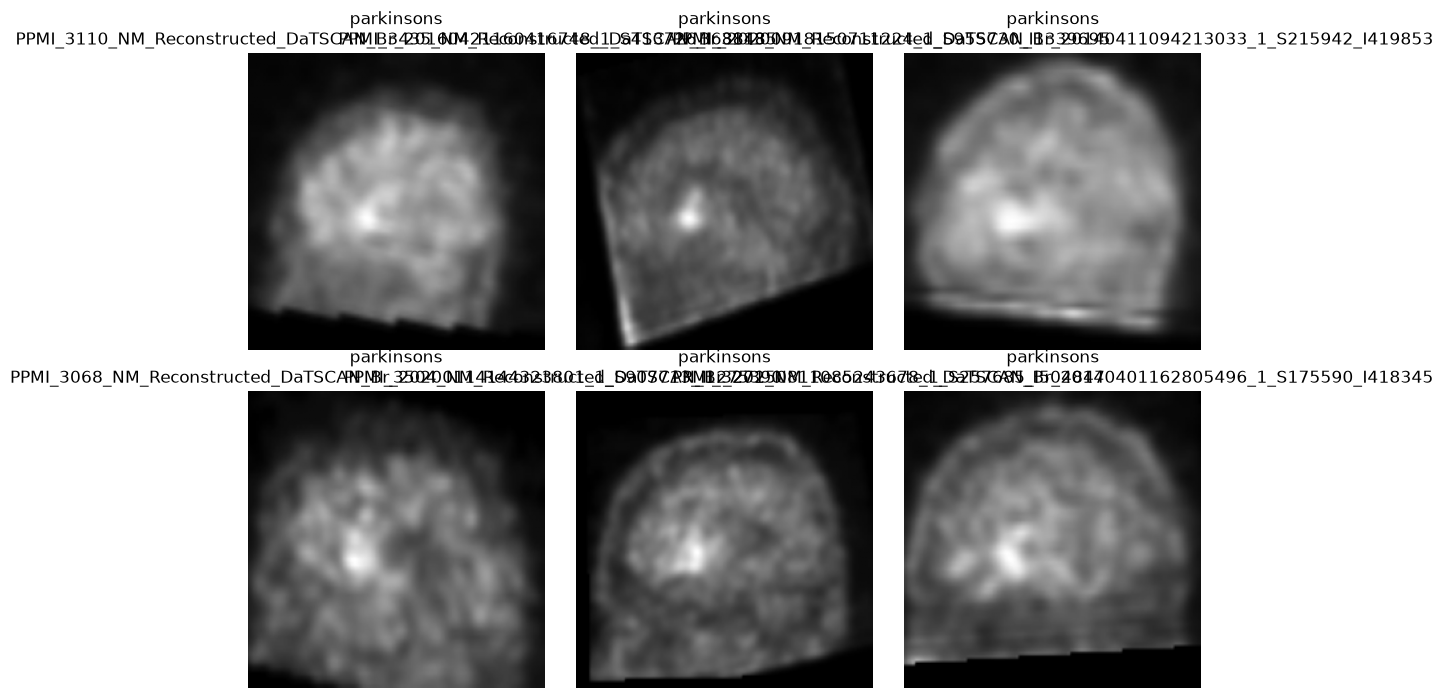

In [113]:
# Create a figure containing 6 subplots arranged in 2 rows and 3 columns
fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 7)
)

# Convert the 2D array of subplot axes into a single flat list
axes = axes.flatten()


# Loop through each subplot and each randomly selected metadata row
for ax, (_, row) in zip(
    axes,
    sample.iterrows()
):

    # Open the processed MRI image from its saved file path
    image = Image.open(
        row[
            "processed_file"
        ]
    )

    # Display the MRI image in grayscale
    ax.imshow(
        image,
        cmap="gray"
    )

    # Add the class label and subject ID as the title
    ax.set_title(
        f"{row['class']}\n"
        f"{row['subject_id']}"
    )

    # Hide the axis labels and tick marks
    ax.axis("off")


# Adjust spacing between the subplots
plt.tight_layout()

# Display the sample MRI images
plt.show()